In [3]:
# Install Java
!apt-get update -qq > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download Apache Spark (using the version from the slides or a stable archive)
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz

# Unzip the Spark file
!tar xf spark-3.4.1-bin-hadoop3.tgz

# Install findspark to connect Python with Spark
!pip install -q findspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [4]:
import os
import findspark

# Set environment variables
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"

# Initialize findspark
findspark.init()

# Create Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Big Data Tutorial").getOrCreate()
print("Spark Session Created Successfully!")

Spark Session Created Successfully!


In [5]:
# Define data
data = [("Tal", 120), ("Uri", 90), ("Dina", 150)]
columns = ["name", "price"]

# Create DataFrame
df = spark.createDataFrame(data, columns)

# Show the table
print("Original Data:")
df.show()

# Filter where price > 100
print("Filtered Data (Price > 100):")
df.filter(df["price"] > 100).show()

Original Data:
+----+-----+
|name|price|
+----+-----+
| Tal|  120|
| Uri|   90|
|Dina|  150|
+----+-----+

Filtered Data (Price > 100):
+----+-----+
|name|price|
+----+-----+
| Tal|  120|
|Dina|  150|
+----+-----+



In [6]:
# Simulated Log Data
logs = [
    "192.168.1.10 - [10/May/2025:13:00] GET /index.html",
    "172.16.0.5 - - [10/May/2025:13:01] GET /contact.html",
    "192.168.1.10 - [10/May/2025:13:02] GET /products.html",
    "10.0.0.1 - - [10/May/2025:13:02] GET /index.html",
    "192.168.1.10 - [10/May/2025:13:03] GET /about.html"
]

# Create RDD
rdd = spark.sparkContext.parallelize(logs)

# MAP Step: Extract IP and map to (IP, 1)
# We split the line and take the first element (the IP)
ip_counts_map = rdd.map(lambda line: (line.split()[0], 1))

# REDUCE Step: Sum counts by IP
ip_counts_reduce = ip_counts_map.reduceByKey(lambda a, b: a + b)

# Collect and Print
print("IP Visit Counts:")
for ip, count in ip_counts_reduce.collect():
    print(f"{ip} visited {count} times")

IP Visit Counts:
172.16.0.5 visited 1 times
192.168.1.10 visited 3 times
10.0.0.1 visited 1 times


In [7]:
import kagglehub
from pyspark.sql.functions import col

# Download the dataset
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")
print("Path to dataset files:", path)

# Load CSV into Spark DataFrame
# Note: We use the actual path returned by kagglehub + the filename usually found there
# We usually need to find the specific CSV file in that folder:
import glob
csv_files = glob.glob(f"{path}/*.csv")
csv_file_path = csv_files[0] if csv_files else None

if csv_file_path:
    df_amazon = spark.read.csv(csv_file_path, header=True, inferSchema=True)

    # Filter out null reviews and select text
    df_clean = df_amazon.select(col('`reviews.text`').alias("review")).filter(col("review").isNotNull())

    # Create RDD
    rdd_text = df_clean.select("review").rdd.map(lambda row: row["review"])

    # MapReduce Word Count
    # 1. Split lines into words (flatMap)
    # 2. Map word to (word, 1)
    # 3. Reduce by key (sum)
    word_counts = rdd_text.flatMap(lambda line: line.lower().split()) \
                          .map(lambda word: (word, 1)) \
                          .reduceByKey(lambda a, b: a + b)

    # Sort by count descending and show top 10
    print("\nTop 10 most common words:")
    top_words = word_counts.takeOrdered(10, key=lambda x: -x[1])
    for word, count in top_words:
        print(f"{word}: {count}")

else:
    print("Could not find CSV file in the downloaded path.")

Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products

Top 10 most common words:
the: 4992
to: 3761
and: 3711
i: 3265
it: 2753
for: 2598
a: 2482
is: 2226
my: 2124
this: 1782


In [8]:
import csv
import random

# Create a dummy CSV file named 'sensor_data.csv'
header = ["timestamp", "sensor_type", "value"]
data = []
sensors = ["temperature", "humidity", "pressure"]

for i in range(100):
    s_type = random.choice(sensors)
    # Temp between 20-35, Humidity 30-80, Pressure 1000-1020
    val = random.uniform(20, 35) if s_type == "temperature" else \
          random.uniform(30, 80) if s_type == "humidity" else \
          random.uniform(1000, 1020)
    data.append([f"2025-05-10 10:{i:02d}", s_type, val])

with open("sensor_data.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(data)

print("Created sensor_data.csv")

Created sensor_data.csv


--- Results ---
Max Values: [('temperature', 34.84121692562004), ('humidity', 76.99339671495676), ('pressure', 1017.7235204339323)]
Min Values: [('temperature', 20.408548254939607), ('humidity', 30.494373209726607), ('pressure', 1001.1344331301061)]


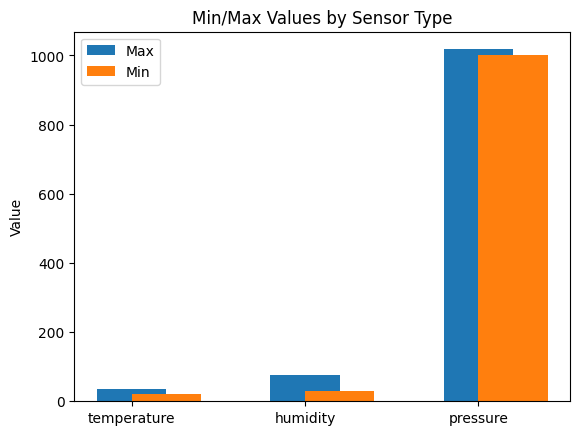

In [9]:
import matplotlib.pyplot as plt

# 1. Load Data
df_sensors = spark.read.csv("sensor_data.csv", header=True, inferSchema=True)

# 2. Convert to RDD: (sensor_type, value)
rdd_sensors = df_sensors.select("sensor_type", "value").rdd.map(lambda row: (row["sensor_type"], row["value"]))

# 3. MapReduce for MAXIMUM
# Reduce logic: Compare a and b, keep the larger one
max_vals = rdd_sensors.reduceByKey(lambda a, b: a if a > b else b).collect()

# 4. MapReduce for MINIMUM
# Reduce logic: Compare a and b, keep the smaller one
min_vals = rdd_sensors.reduceByKey(lambda a, b: a if a < b else b).collect()

# Display Results
print("--- Results ---")
print("Max Values:", max_vals)
print("Min Values:", min_vals)

# 5. Visualize (Bonus Graph)
# Organize data for plotting
categories = [x[0] for x in max_vals]
max_values = [x[1] for x in max_vals]
min_values = [x[1] for x in min_vals] # Note: ensure order matches if using real data, dict lookup is safer

# Simple Bar Chart
x_axis = range(len(categories))
plt.bar(x_axis, max_values, width=0.4, label='Max', align='center')
plt.bar(x_axis, min_values, width=0.4, label='Min', align='edge')
plt.xticks(x_axis, categories)
plt.ylabel("Value")
plt.title("Min/Max Values by Sensor Type")
plt.legend()
plt.show()